# Experimento de Programação Dinâmica no FrozenLake

Este notebook implementa o experimento proposto para o ambiente **FrozenLake-v1 4×4**, utilizando como referência conceitual a implementação-base disponibilizada na disciplina.

Serão comparados:

- **Policy Iteration**
- **Value Iteration**

em duas configurações do ambiente:

- **Determinística** (`is_slippery=False`)
- **Estocástica** (`is_slippery=True`)

O objetivo é comparar as políticas obtidas, os valores dos estados, o comportamento de convergência e o desempenho das políticas quando executadas no ambiente.

## 1. Configuração experimental


### 1.1 Dependências

In [16]:
%pip install gymnasium numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

%matplotlib inline


### 1.2 Parâmetros


Como o experimento utiliza **Programação Dinâmica**, não existem parâmetros de aprendizagem como taxa de aprendizado (`alpha`) ou exploração ε-greedy.

Os parâmetros relevantes são:

- `GAMMA`: fator de desconto;
- `THETA`: tolerância utilizada como critério de convergência;
- `N_EVAL_EPISODES`: número de episódios usados apenas na avaliação final;
- `SEED`: semente para reprodutibilidade da avaliação.


In [ ]:
SEED = 42
GAMMA = 1.0
THETA = 1e-8
N_EVAL_EPISODES = 1000

### 1.3 Ambientes

São criados dois ambientes FrozenLake 4×4 com o mesmo mapa.

No ambiente **determinístico**, cada ação leva ao resultado definido pelo modelo de transição.

No ambiente **estocástico**, a ação escolhida pode resultar em diferentes transições devido à superfície escorregadia.


In [3]:
env_deterministic = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False,
    render_mode="rgb_array"
)

env_stochastic = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True,
    render_mode="rgb_array"
)

environments = {
    "Determinístico": env_deterministic,
    "Estocástico": env_stochastic,
}

STATE_SPACE_SIZE = env_deterministic.observation_space.n
ACTION_SPACE_SIZE = env_deterministic.action_space.n
GRID_SIDE_SIZE = int(np.sqrt(STATE_SPACE_SIZE))

print("Estados:", STATE_SPACE_SIZE)
print("Ações:", ACTION_SPACE_SIZE)
print("Mapa:")
print(env_deterministic.unwrapped.desc.astype(str))


Estados: 16
Ações: 4
Mapa:
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]


## 2. Funções de Programação Dinâmica

As funções abaixo implementam o experimento.

A dinâmica do ambiente é conhecida e pode ser consultada por:

```python
env.get_wrapper_attr("P")[s][a]
```

Para cada estado `s` e ação `a`, o modelo informa probabilidades de transição, próximo estado, recompensa e término.

### 2.1 Policy Evaluation

A avaliação de política calcula:

$$
V_\pi(s)=
\sum_a \pi(a|s)
\sum_{s'}P(s'|s,a)
\left[R(s,a,s')+\gamma V_\pi(s')\right]
$$

A avaliação é repetida até que a maior alteração de valor entre duas varreduras seja inferior a `THETA`.


In [4]:
def policy_evaluation(env, policy, gamma=1.0, theta=1e-8):
    # Avalia uma política até a convergência da função V.
    V = np.zeros(env.observation_space.n)
    delta_history = []

    while True:
        delta = 0.0

        for s in range(env.observation_space.n):
            Vs = 0.0

            for a, action_prob in enumerate(policy[s]):
                for prob, next_state, reward, done in env.get_wrapper_attr("P")[s][a]:
                    future_value = 0.0 if done else gamma * V[next_state]
                    Vs += action_prob * prob * (reward + future_value)

            delta = max(delta, abs(V[s] - Vs))
            V[s] = Vs

        delta_history.append(delta)

        if delta < theta:
            break

    return V, delta_history


### 2.2 Valor das ações a partir de V

Para um estado `s`:

$$
Q(s,a)=
\sum_{s'}P(s'|s,a)
\left[R(s,a,s')+\gamma V(s')\right]
$$

Aqui, `Q` é **derivado de V e do modelo conhecido do ambiente**. Ele é apenas um cálculo auxiliar para melhorar ou extrair a política; não está sendo aprendido por Q-Learning.


In [5]:
def q_value(env, V, s, gamma=1.0):
    # Calcula os valores Q(s,a) de todas as ações de um estado.
    q = np.zeros(env.action_space.n)

    for a in range(env.action_space.n):
        for prob, next_state, reward, done in env.get_wrapper_attr("P")[s][a]:
            future_value = 0.0 if done else gamma * V[next_state]
            q[a] += prob * (reward + future_value)

    return q


def compute_q_table(env, V, gamma=1.0):
    # Constrói a matriz completa Q a partir de V.
    Q = np.zeros((env.observation_space.n, env.action_space.n))

    for s in range(env.observation_space.n):
        Q[s] = q_value(env, V, s, gamma)

    return Q


### 2.3 Policy Improvement

A melhoria da política seleciona, para cada estado, as ações com maior valor.

Quando há empate entre ações ótimas, a probabilidade é distribuída igualmente entre elas.


In [6]:
def policy_improvement(env, V, gamma=1.0):
    # Constrói uma política melhor a partir da função V.
    policy = np.zeros(
        (env.observation_space.n, env.action_space.n)
    )

    for s in range(env.observation_space.n):
        q = q_value(env, V, s, gamma)

        best_actions = np.flatnonzero(
            np.isclose(q, np.max(q))
        )

        policy[s, best_actions] = 1.0 / len(best_actions)

    return policy


### 2.4 Policy Iteration

O **Policy Iteration** alterna:

1. **Policy Evaluation**: calcula `V` para a política atual;
2. **Policy Improvement**: gera uma nova política a partir dos valores obtidos.

O processo termina quando a política deixa de mudar.

O histórico registra quantas varreduras de Policy Evaluation foram necessárias em cada iteração externa.


In [7]:
def policy_iteration(env, gamma=1.0, theta=1e-8):
    # Executa Policy Iteration até a política se tornar estável.
    policy = np.ones(
        (env.observation_space.n, env.action_space.n)
    ) / env.action_space.n

    history = {
        "evaluation_iterations": [],
        "policy_changes": [],
    }

    while True:
        V, evaluation_history = policy_evaluation(
            env,
            policy,
            gamma,
            theta
        )

        history["evaluation_iterations"].append(
            len(evaluation_history)
        )

        new_policy = policy_improvement(
            env,
            V,
            gamma
        )

        policy_change = np.max(
            np.abs(new_policy - policy)
        )

        history["policy_changes"].append(
            policy_change
        )

        if np.allclose(policy, new_policy, atol=theta):
            policy = new_policy
            break

        policy = new_policy

    V, _ = policy_evaluation(
        env,
        policy,
        gamma,
        theta
    )

    return policy, V, history


### 2.5 Value Iteration

O **Value Iteration** aplica diretamente a equação ótima de Bellman:

$$
V(s)\leftarrow
\max_a
\sum_{s'}P(s'|s,a)
\left[R(s,a,s')+\gamma V(s')\right]
$$

A política é extraída depois que a função de valor converge.


In [8]:
def value_iteration(env, gamma=1.0, theta=1e-8):
    # Executa Value Iteration até a convergência de V.
    V = np.zeros(env.observation_space.n)
    delta_history = []

    while True:
        delta = 0.0

        for s in range(env.observation_space.n):
            old_value = V[s]

            V[s] = np.max(
                q_value(env, V, s, gamma)
            )

            delta = max(
                delta,
                abs(V[s] - old_value)
            )

        delta_history.append(delta)

        if delta < theta:
            break

    policy = policy_improvement(
        env,
        V,
        gamma
    )

    return policy, V, delta_history


## 3. Execução dos experimentos

São executadas quatro combinações:

| Ambiente | Algoritmo |
|---|---|
| Determinístico | Policy Iteration |
| Determinístico | Value Iteration |
| Estocástico | Policy Iteration |
| Estocástico | Value Iteration |

Os resultados são armazenados em um único dicionário para facilitar as comparações.


In [9]:
results = {}

for env_name, env in environments.items():

    policy_pi, V_pi, history_pi = policy_iteration(
        env,
        gamma=GAMMA,
        theta=THETA
    )

    policy_vi, V_vi, history_vi = value_iteration(
        env,
        gamma=GAMMA,
        theta=THETA
    )

    results[(env_name, "Policy Iteration")] = {
        "policy": policy_pi,
        "V": V_pi,
        "history": history_pi,
    }

    results[(env_name, "Value Iteration")] = {
        "policy": policy_vi,
        "V": V_vi,
        "history": history_vi,
    }

for (env_name, algorithm), result in results.items():
    result["Q"] = compute_q_table(
        environments[env_name],
        result["V"],
        gamma=GAMMA
    )

print("Experimentos concluídos:", len(results))


Experimentos concluídos: 4


## 4. Função de valor V(s)

Os heatmaps mostram os valores atribuídos aos 16 estados após a convergência.

Estados terminais possuem valor zero porque a recompensa é recebida **na transição que leva ao estado terminal**, e não depois que o agente já se encontra nele.


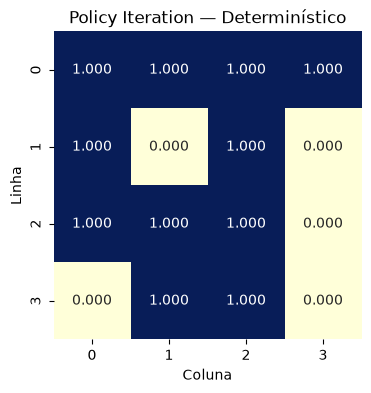

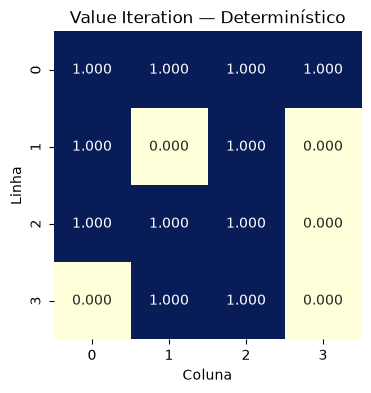

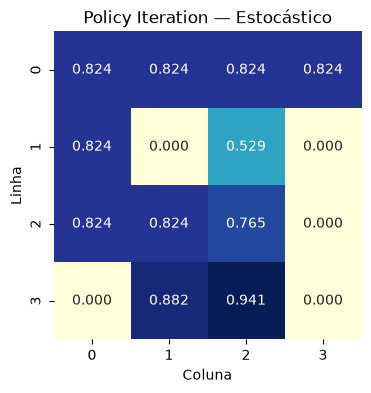

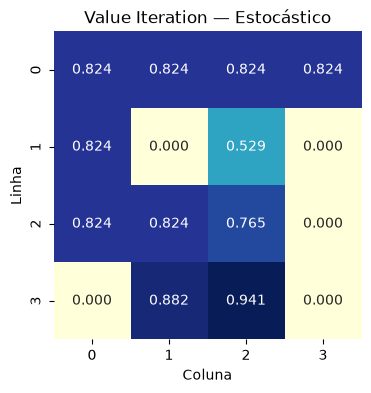

In [10]:
for (env_name, algorithm), result in results.items():
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        result["V"].reshape(GRID_SIDE_SIZE, GRID_SIDE_SIZE),
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        cbar=False,
        square=True
    )

    plt.title(f"{algorithm} — {env_name}")
    plt.xlabel("Coluna")
    plt.ylabel("Linha")
    plt.show()


## 5. Política final no tabuleiro

A política é visualizada diretamente sobre o mapa 4×4.

- `←` = LEFT
- `↓` = DOWN
- `→` = RIGHT
- `↑` = UP

Quando aparecem várias setas em uma mesma célula, existem **múltiplas ações com o mesmo valor ótimo**.

Estados `H` e `G` não recebem setas porque são terminais.


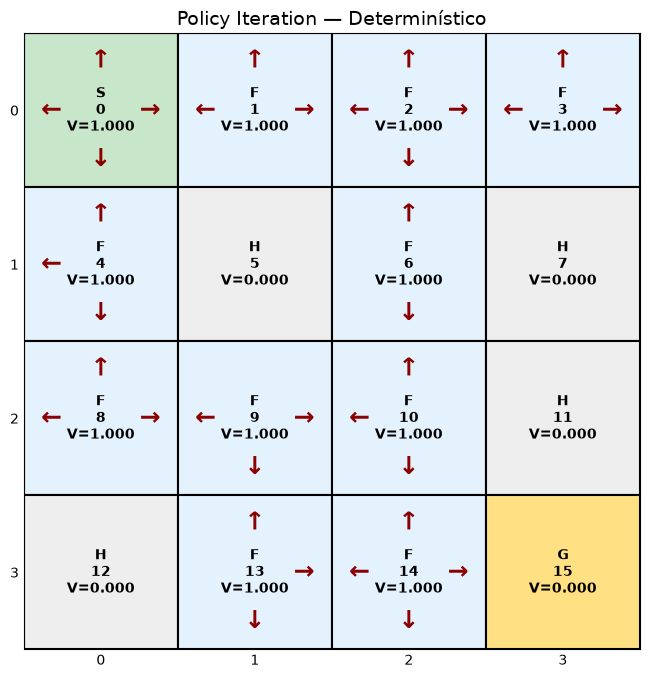

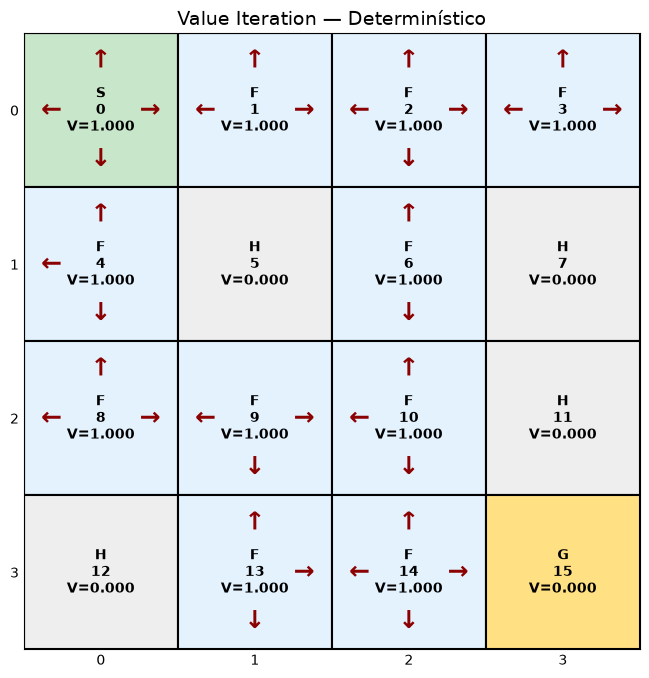

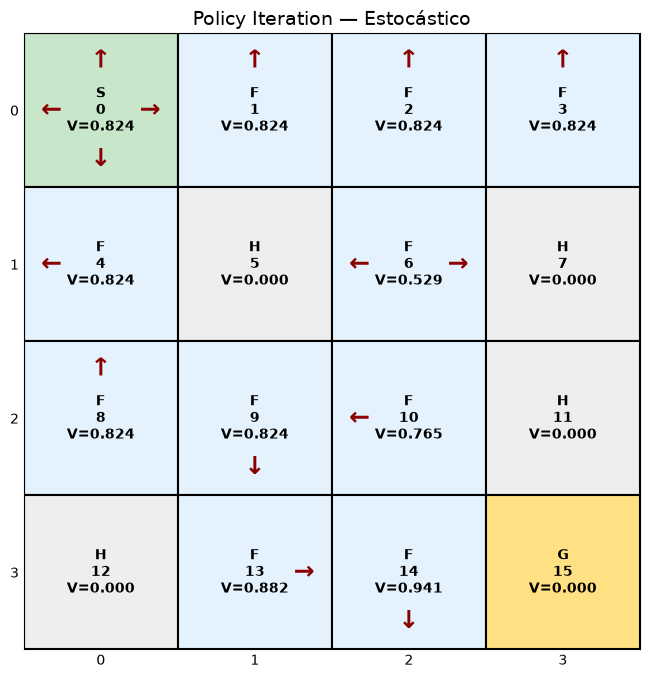

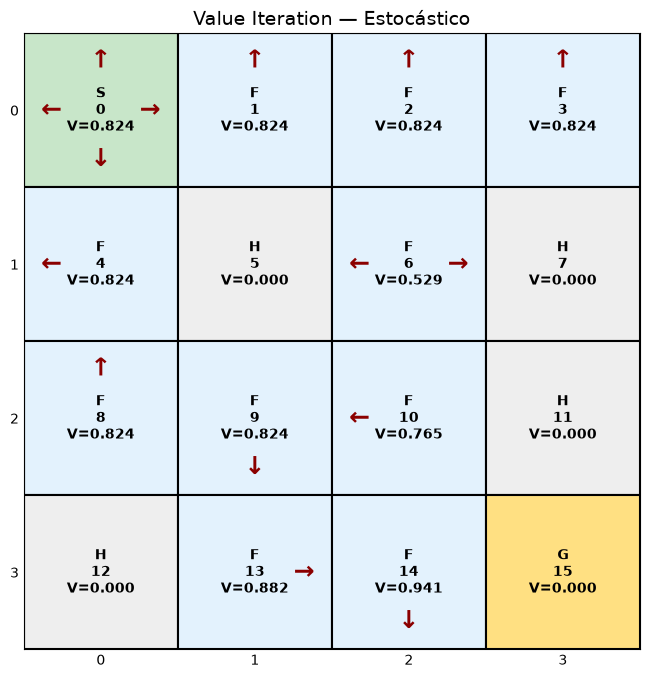

In [11]:
from matplotlib.patches import Rectangle


def plot_policy_arrows(env, Q, V=None, title="Política"):
    # Plota o FrozenLake com as melhores ações representadas por setas.
    desc = env.unwrapped.desc.astype(str)
    nrows, ncols = desc.shape

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    cell_colors = {
        "S": "#c8e6c9",
        "F": "#e3f2fd",
        "H": "#eeeeee",
        "G": "#ffe082",
    }

    arrow_positions = {
        0: (0.18, 0.50, "←"),  # LEFT
        1: (0.50, 0.82, "↓"),  # DOWN
        2: (0.82, 0.50, "→"),  # RIGHT
        3: (0.50, 0.18, "↑"),  # UP
    }

    for r in range(nrows):
        for c in range(ncols):
            s = r * ncols + c
            cell_type = desc[r, c]

            rect = Rectangle(
                (c, r),
                1,
                1,
                facecolor=cell_colors.get(cell_type, "white"),
                edgecolor="black",
                linewidth=1.5,
            )
            ax.add_patch(rect)

            center_label = f"{cell_type}\n{s}"

            if V is not None:
                center_label += f"\nV={V[s]:.3f}"

            ax.text(
                c + 0.5,
                r + 0.5,
                center_label,
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
            )

            if cell_type in ("H", "G"):
                continue

            best_actions = np.flatnonzero(
                np.isclose(Q[s], np.max(Q[s]))
            )

            for a in best_actions:
                x_rel, y_rel, arrow = arrow_positions[a]

                ax.text(
                    c + x_rel,
                    r + y_rel,
                    arrow,
                    ha="center",
                    va="center",
                    fontsize=18,
                    fontweight="bold",
                    color="darkred",
                )

    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_yticks(np.arange(nrows) + 0.5)
    ax.set_xticklabels(range(ncols))
    ax.set_yticklabels(range(nrows))
    ax.set_title(title, fontsize=14)
    ax.tick_params(length=0)

    plt.show()


for (env_name, algorithm), result in results.items():
    plot_policy_arrows(
        environments[env_name],
        result["Q"],
        V=result["V"],
        title=f"{algorithm} — {env_name}"
    )


## 6. Análise de convergência

### 6.1 Value Iteration

Para Value Iteration, é registrado:

$$
\Delta_k = \max_s |V_{k+1}(s)-V_k(s)|
$$

A curva mostra como a função de valor se aproxima da convergência.

O eixo Y é logarítmico porque o critério adotado é `THETA = 1e-8`.

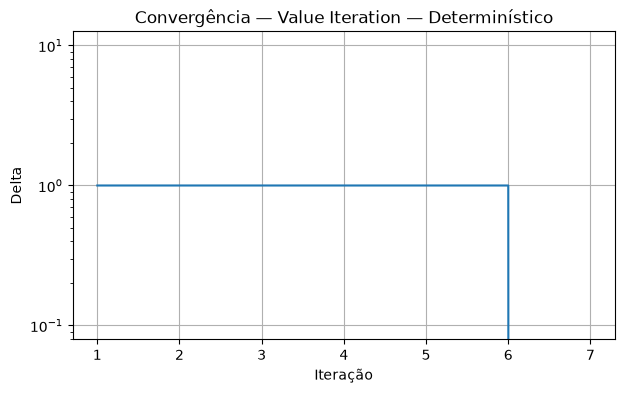

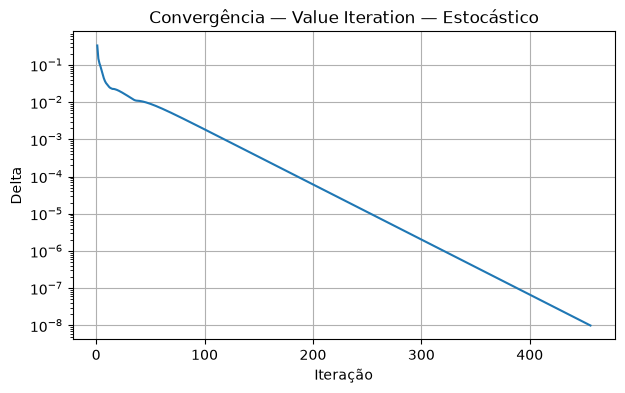

In [12]:
for env_name in environments:
    history = results[
        (env_name, "Value Iteration")
    ]["history"]

    plt.figure(figsize=(7, 4))

    plt.plot(
        range(1, len(history) + 1),
        history
    )

    plt.yscale("log")
    plt.xlabel("Iteração")
    plt.ylabel("Delta")
    plt.title(
        f"Convergência — Value Iteration — {env_name}"
    )
    plt.grid(True)
    plt.show()


### 6.2 Policy Iteration

Para Policy Iteration, cada ponto mostra **quantas varreduras de Policy Evaluation foram necessárias para avaliar a política daquela iteração externa**.

Esse gráfico representa o **custo da avaliação das políticas intermediárias**, e não uma medida direta da recompensa ou da qualidade da política.

Um aumento no número de varreduras significa apenas que aquela política exigiu mais iterações numéricas para satisfazer o critério `THETA`.


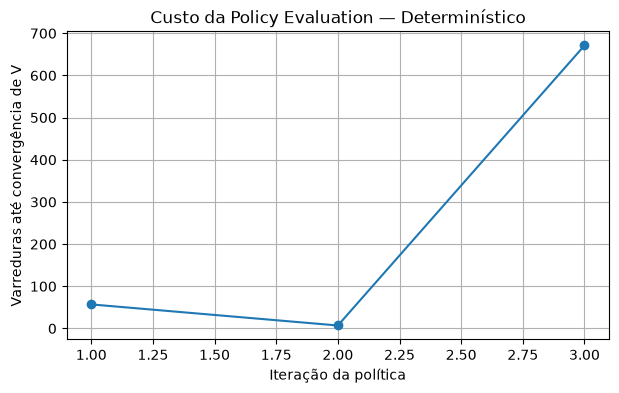

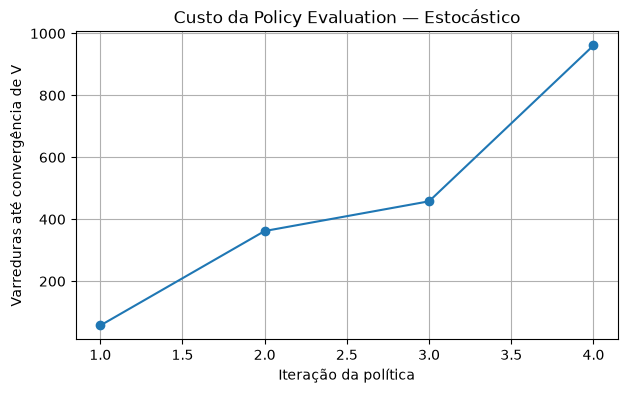

In [13]:
for env_name in environments:
    history = results[
        (env_name, "Policy Iteration")
    ]["history"]

    evaluation_iterations = history[
        "evaluation_iterations"
    ]

    plt.figure(figsize=(7, 4))

    plt.plot(
        range(1, len(evaluation_iterations) + 1),
        evaluation_iterations,
        marker="o"
    )

    plt.xlabel("Iteração da política")
    plt.ylabel("Varreduras até convergência de V")
    plt.title(
        f"Custo da Policy Evaluation — {env_name}"
    )
    plt.grid(True)
    plt.show()


## 7. Avaliação das políticas em episódios

A Programação Dinâmica encontra a política utilizando o modelo conhecido do ambiente.

Depois disso, as políticas são executadas em episódios reais do FrozenLake apenas para **avaliação experimental**.

São coletadas:

- recompensa total por episódio;
- taxa de sucesso;
- número de passos até o término;
- média e desvio padrão das recompensas.

A execução respeita o limite de passos do ambiente (`TimeLimit`).


In [14]:
def evaluate_policy(env, policy, episodes=1000, seed=42):
    # Executa uma política e coleta métricas de avaliação.
    rewards = []
    steps_per_episode = []
    successes = []

    rng = np.random.default_rng(seed)

    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)

        terminated = False
        truncated = False

        total_reward = 0.0
        steps = 0

        while not (terminated or truncated):
            action = rng.choice(
                env.action_space.n,
                p=policy[state]
            )

            state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            steps += 1

        rewards.append(total_reward)
        steps_per_episode.append(steps)
        successes.append(total_reward > 0)

    return {
        "rewards": np.asarray(rewards),
        "steps": np.asarray(steps_per_episode),
        "successes": np.asarray(successes),
    }


for (env_name, algorithm), result in results.items():
    result["evaluation"] = evaluate_policy(
        environments[env_name],
        result["policy"],
        episodes=N_EVAL_EPISODES,
        seed=SEED
    )


## 8. Comparação quantitativa

A tabela resume o desempenho das políticas durante a avaliação por episódios.

Como a recompensa do FrozenLake é binária (`0` ou `1`), a recompensa média também corresponde à proporção de episódios que chegaram ao objetivo.

In [15]:
rows = []

for (env_name, algorithm), result in results.items():
    evaluation = result["evaluation"]

    rows.append({
        "Ambiente": env_name,
        "Algoritmo": algorithm,
        "Recompensa média": np.mean(evaluation["rewards"]),
        "Desvio padrão": np.std(evaluation["rewards"]),
        "Taxa de sucesso": np.mean(evaluation["successes"]),
        "Passos médios": np.mean(evaluation["steps"]),
        "Iterações principais": (
            len(result["history"]["evaluation_iterations"])
            if algorithm == "Policy Iteration"
            else len(result["history"])
        ),
    })

results_df = pd.DataFrame(rows)
results_df


,Ambiente,Algoritmo,Recompensa média,Desvio padrão,Taxa de sucesso,Passos médios,Iterações principais
0,Determinístico,Policy Iteration,0.742,0.437534,0.742,60.939,3
1,Determinístico,Value Iteration,0.742,0.437534,0.742,60.939,7
2,Estocástico,Policy Iteration,0.534,0.498843,0.534,63.549,4
3,Estocástico,Value Iteration,0.534,0.498843,0.534,63.549,456


## 9. Pontos para análise no relatório

Os resultados deste notebook permitem discutir:

1. **Policy Iteration × Value Iteration**  
   Verificar se os algoritmos convergem para a mesma função de valor e para políticas equivalentes.

2. **Determinístico × Estocástico**  
   Observar como a incerteza nas transições altera os valores dos estados, as melhores ações e o custo de convergência.

3. **Empates entre ações ótimas**  
   Com `GAMMA = 1` e recompensa apenas no objetivo, diferentes ações podem possuir o mesmo retorno ótimo. Por isso algumas células podem apresentar múltiplas setas.

4. **Custo de convergência**  
   Policy Iteration e Value Iteration usam mecanismos diferentes. O primeiro realiza avaliações completas de políticas intermediárias; o segundo aplica diretamente atualizações de Bellman ótimo.

5. **Limitação da Programação Dinâmica**  
   Os algoritmos dependem do conhecimento explícito do modelo de transição e recompensa do ambiente.


## 10. Correspondência com o relatório

| Seção do relatório | Evidência produzida pelo notebook |
|---|---|
| Introdução | objetivo e comparação determinístico × estocástico |
| Fundamentação Teórica | Policy Iteration, Value Iteration, V e cálculo auxiliar de Q |
| Metodologia | parâmetros, ambientes e critérios de convergência |
| Resultados | heatmaps de V, políticas no tabuleiro, curvas de convergência e tabela final |
| Discussão | diferenças de convergência, efeito da estocasticidade e empates |
| Conclusões | comparação geral entre os algoritmos e ambientes |
